# Notebook 4: Customer Segmentation (RFM Analysis)
**Dataset:** Sample Superstore (Cleaned)  
**Goal:** Score every customer on Recency, Frequency, and Monetary value. 
Segment customers into actionable groups to drive retention and revenue strategy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid')


## Section 1: Load Data


In [2]:
df = pd.read_csv('../data/processed/superstore_cleaned.csv', parse_dates=['Order Date', 'Ship Date'], dtype={'Postal Code': 'string'})
print(df.shape)


(9993, 25)


## Section 2: Calculate RFM Metrics


In [3]:
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")


Reference date: 2017-12-31 00:00:00


In [4]:
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm.head(10)


,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156
5,AB-10060,55,8,7755.620
6,AB-10105,42,10,14473.571
7,AB-10150,42,5,966.710
8,AB-10165,26,8,1113.838
9,AB-10255,167,9,914.532


In [5]:
print(f"Total unique customers: {len(rfm)}")
print(f"\nRFM Summary Stats:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))


Total unique customers: 793

RFM Summary Stats:
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32   2896.49
std     186.21       2.55   2628.41
min       1.00       1.00      4.83
25%      31.00       5.00   1146.05
50%      76.00       6.00   2256.39
75%     184.00       8.00   3785.28
max    1166.00      17.00  25043.05


In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head(10)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,185,5,5563.560,1,1,4,114
1,AA-10375,20,9,1056.390,4,4,1,441
2,AA-10480,260,4,1790.512,1,1,2,112
3,AA-10645,56,6,5086.935,3,2,4,324
4,AB-10015,416,3,886.156,1,1,1,111
5,AB-10060,55,8,7755.620,3,3,4,334
6,AB-10105,42,10,14473.571,3,4,4,344
7,AB-10150,42,5,966.710,3,1,1,311
8,AB-10165,26,8,1113.838,4,3,1,431
9,AB-10255,167,9,914.532,2,4,1,241


In [7]:
# Dynamically calculate RFM quartile thresholds from data
r_bins = pd.qcut(rfm['Recency'], q=4, retbins=True)[1]
f_bins = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, retbins=True)[1]
m_bins = pd.qcut(rfm['Monetary'], q=4, retbins=True)[1]

# Map rank percentiles back to actual frequency values
freq_q = rfm['Frequency'].quantile([0.25, 0.5, 0.75]).values.astype(int)

rfm_thresholds = pd.DataFrame({
    'Score': [1, 2, 3, 4],
    'Recency (days)': [
        f"{int(r_bins[3])} – {int(r_bins[4])}",
        f"{int(r_bins[2])} – {int(r_bins[3])}",
        f"{int(r_bins[1])} – {int(r_bins[2])}",
        f"0 – {int(r_bins[1])}"
    ],
    'Frequency (orders)': [
        f"1 – {freq_q[0]}",
        f"{freq_q[0]} – {freq_q[1]}",
        f"{freq_q[1]} – {freq_q[2]}",
        f"{freq_q[2]}+"
    ],
    'Monetary ($ spend)': [
        f"${m_bins[0]:,.0f} – ${m_bins[1]:,.0f}",
        f"${m_bins[1]:,.0f} – ${m_bins[2]:,.0f}",
        f"${m_bins[2]:,.0f} – ${m_bins[3]:,.0f}",
        f"${m_bins[3]:,.0f} – ${m_bins[4]:,.0f}"
    ]
})

print("RFM Score Thresholds (1 = lowest, 4 = highest) — calculated from data quartiles\n")
print(rfm_thresholds.to_string(index=False))

RFM Score Thresholds (1 = lowest, 4 = highest) — calculated from data quartiles

 Score Recency (days) Frequency (orders) Monetary ($ spend)
     1     184 – 1166              1 – 5        $5 – $1,146
     2       76 – 184              5 – 6    $1,146 – $2,256
     3        31 – 76              6 – 8    $2,256 – $3,785
     4         0 – 31                 8+   $3,785 – $25,043


**Score interpretation:** A score of 4 always represents the best quartile. 
Recency is inverse-scored — fewer days since purchase = higher score. 
Customers in the top quartile on all three metrics (R=4, F=4, M=4) are classified as Champions.

## Section 4: Customer Segments


In [8]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    else:
        return 'Inactive / Low Value'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm['Segment'].value_counts()


Segment
Inactive / Low Value    351
New Customer            159
Loyal                   142
At Risk                  80
Champion                 34
Cannot Lose              27
Name: count, dtype: int64

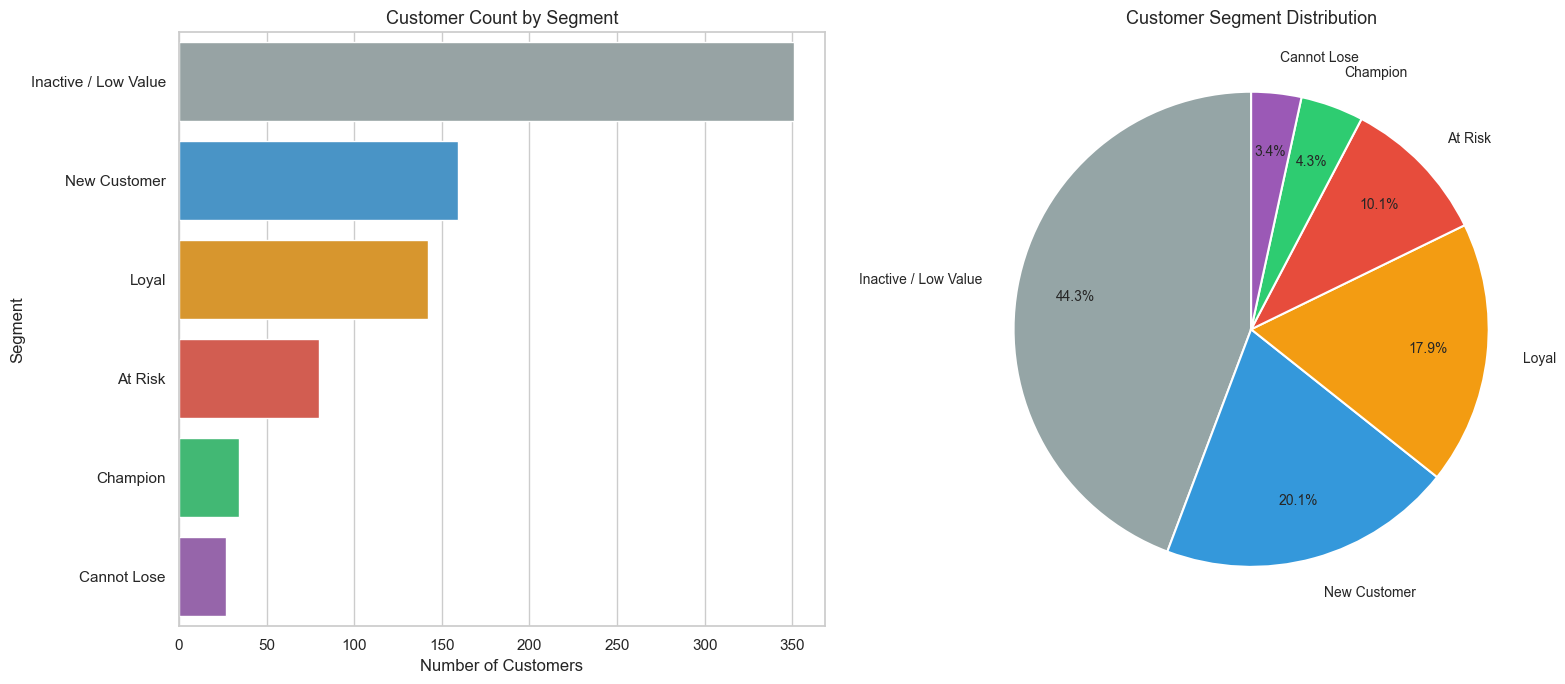

In [9]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

color_map = {
    'Inactive / Low Value': '#95a5a6',
    'New Customer':         '#3498db',
    'Loyal':                '#f39c12',
    'At Risk':              '#e74c3c',
    'Champion':             '#2ecc71',
    'Cannot Lose':          '#9b59b6'
}

colors = [color_map[s] for s in segment_counts['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=segment_counts, x='Count', y='Segment',
            hue='Segment', palette=color_map, legend=False, ax=axes[0])
axes[0].set_title('Customer Count by Segment', fontsize=13)
axes[0].set_xlabel('Number of Customers')

axes[1].pie(segment_counts['Count'], labels=segment_counts['Segment'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            pctdistance=0.75, labeldistance=1.15,
            textprops={'fontsize': 10},
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
axes[1].set_title('Customer Segment Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/figures/04_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()




**Finding:** The largest group is inactive/low-value customers based on the RFM reference date. 
Only 4.3% are Champions. At Risk and Cannot Lose customers represent the most 
urgent retention opportunities because they are valuable customers showing signs of disengagement.


## Section 5: Segment Revenue Analysis


In [10]:
segment_value = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index().round(2)

segment_value['Revenue %'] = (segment_value['Total_Revenue'] / segment_value['Total_Revenue'].sum() * 100).round(2)
segment_value.sort_values('Total_Revenue', ascending=False)


,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue %
3,Inactive / Low Value,351,249.41,5.28,1727.17,606235.60,26.39
4,Loyal,142,37.36,8.50,4250.50,603571.47,26.28
5,New Customer,159,34.96,4.52,2247.42,357340.16,15.56
0,At Risk,80,166.11,7.74,4374.94,349995.49,15.24
2,Champion,34,16.00,10.09,5863.65,199364.00,8.68
1,Cannot Lose,27,183.96,10.00,6681.95,180412.77,7.85


/var/folders/gf/f7jctzc95n310yq03jtxx38c0000gn/T/ipykernel_44210/35109232.py:3: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=segment_value.sort_values('Total_Revenue', ascending=False),


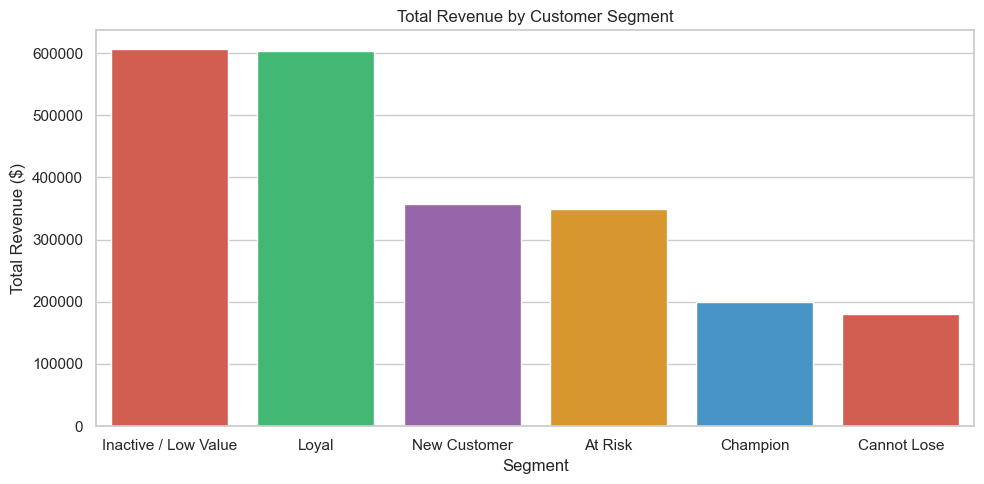

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=segment_value.sort_values('Total_Revenue', ascending=False),
            x='Segment', y='Total_Revenue',
            hue='Segment', palette=['#e74c3c','#2ecc71','#9b59b6','#f39c12','#3498db'],
            legend=False, ax=ax)

ax.set_title('Total Revenue by Customer Segment')
ax.set_ylabel('Total Revenue ($)')
ax.set_xlabel('Segment')

plt.tight_layout()
plt.savefig('../outputs/figures/04_segment_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Inactive/low-value customers generated substantial historical revenue, while At Risk and Cannot Lose customers have high average spend.
**Priority:** Retain At Risk and Cannot Lose customers immediately. Protect Champions. 
Investigate why a large share of customers shows weak recent engagement.


## Section 6: Save RFM Data


In [12]:
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)
print(f"RFM data saved: {rfm.shape[0]} customers, {rfm.shape[1]} columns")
print(f"\nSegment breakdown:")
print(rfm['Segment'].value_counts())


RFM data saved: 793 customers, 9 columns

Segment breakdown:
Segment
Inactive / Low Value    351
New Customer            159
Loyal                   142
At Risk                  80
Champion                 34
Cannot Lose              27
Name: count, dtype: int64


## Summary

**Method:** RFM (Recency, Frequency, Monetary) scoring — each customer scored 1–4 
on all three dimensions based on quartile ranking.

**Customer Base:** 793 unique customers across 4 years (2014–2017)

**Key Findings:**
- The largest group is inactive/low-value customers as of the RFM reference date
- At Risk and Cannot Lose customers are urgent retention priorities because they combine older recency with stronger frequency/monetary scores
- Champions are the highest-value customers and should be protected with VIP retention tactics
- Customer status is based on historical RFM behavior, not a confirmed churn label

**Recommendations:**
1. Launch immediate retention campaign targeting At Risk and Cannot Lose customers
2. Create VIP program for Champions to prevent churn
3. Build onboarding sequence for New Customers to drive second purchase
4. Investigate root causes behind weak recent engagement
